# What Does an Autoencoder Remember?
## Investigating Latent Dimension and Quality of Reconstruction

**Author:** Owen Nda Diche | **Student ID:** 24152506  
**GitHub:** https://github.com/owendiche-sys/Autoencoder-Latent-Dimension-Tutorial

---

## Overview

This notebook supports the tutorial on autoencoders and the effect of latent dimension on reconstruction quality. We train five identical fully-connected autoencoders on Fashion-MNIST, varying only the latent dimension (2, 8, 16, 32, 64), and compare:

- Final test reconstruction loss (MSE)
- Test loss curves over 15 epochs
- Visual reconstructions side-by-side
- 2D latent space visualisation (for dim=2)
- SSIM (Structural Similarity Index) as a perceptual quality metric

### Key references
- Hinton & Salakhutdinov (2006): https://www.science.org/doi/10.1126/science.1127647
- Goodfellow, Bengio & Courville (2016): https://www.deeplearningbook.org
- Vincent et al. (2010) - Denoising Autoencoders: https://dl.acm.org/doi/10.5555/1756006.1953039
- Fashion-MNIST (Xiao et al., 2017): https://arxiv.org/abs/1708.07747
- PyTorch docs: https://pytorch.org/docs

## Install & Import Dependencies

We use PyTorch for the model, torchvision for the dataset, matplotlib for plots, and scikit-image for SSIM.

In [1]:
# Uncomment if running for the first time
# !pip install torch torchvision matplotlib scikit-image numpy --quiet

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from skimage.metrics import structural_similarity as ssim

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

Using device: cpu
PyTorch version: 2.10.0+cpu


## Load Fashion-MNIST

Fashion-MNIST contains 70,000 greyscale 28×28 images across 10 clothing categories.
We use a subset of the training data (10,000 samples) to keep training fast and reproducible.

**Important:** Autoencoders are trained *without* class labels, the objective is purely to reconstruct the input.

100%|██████████| 26.4M/26.4M [00:01<00:00, 16.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 266kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.02MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.6MB/s]


Training samples: 12000
Test samples:     2000


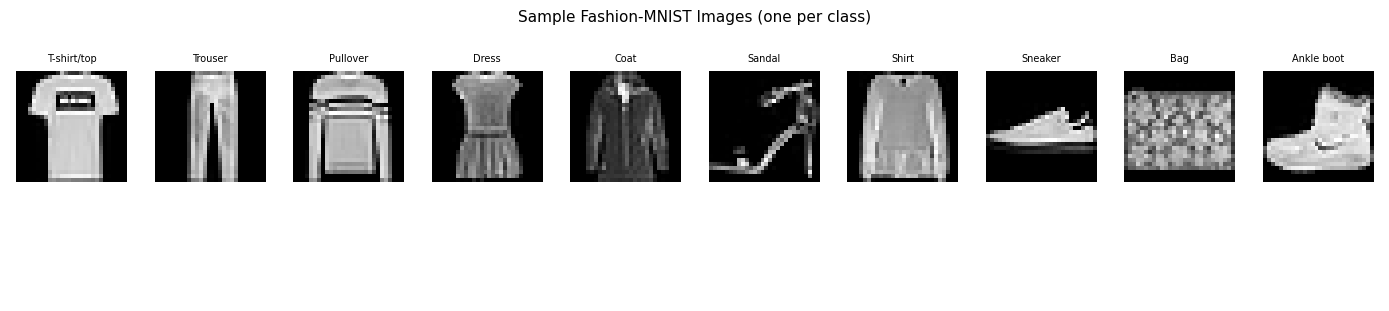

In [2]:
transform = transforms.Compose([
    transforms.ToTensor()  # scales pixels to [0, 1]
])

# Download datasets
train_full = torchvision.datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_full  = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Use a subset for speed , increase TRAIN_SIZE for better results at the cost of time
TRAIN_SIZE = 12000
TEST_SIZE  = 2000
train_data = Subset(train_full, range(TRAIN_SIZE))
test_data  = Subset(test_full,  range(TEST_SIZE))

BATCH_SIZE = 128
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False)

# Class names for visualisation
CLASS_NAMES = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

print(f'Training samples: {len(train_data)}')
print(f'Test samples:     {len(test_data)}')

# Preview some training images
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
fig.suptitle('Sample Fashion-MNIST Images (one per class)', fontsize=11, y=1.02)
for class_idx in range(10):
    # Find first image of each class
    for img, label in train_full:
        if label == class_idx:
            axes[0, class_idx].imshow(img.squeeze(), cmap='gray')
            axes[0, class_idx].set_title(CLASS_NAMES[class_idx], fontsize=7)
            axes[0, class_idx].axis('off')
            axes[1, class_idx].axis('off')
            break
plt.tight_layout()
plt.savefig('fashion_mnist_samples.png', dpi=120, bbox_inches='tight')
plt.show()

## Define the Autoencoder Architecture

The architecture is a **symmetric fully-connected autoencoder**:

```
Input (784) → 256 → 128 → [latent_dim] → 128 → 256 → Output (784)
```

- **ReLU activations** in hidden layers allow non-linear feature learning
- **Sigmoid** on the final output constrains pixel values to [0, 1]
- Only `latent_dim` changes across our five experiments, everything else is constant

This controlled design means the main experimental change is the bottleneck size, although parameter count also increases slightly with larger latent dimensions.

In [3]:
class Autoencoder(nn.Module):
    """
    Symmetric fully-connected autoencoder.

    Args:
        latent_dim (int): Size of the bottleneck (the only parameter varied in tutorial)
    """
    def __init__(self, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder: progressively compresses the input
        self.encoder = nn.Sequential(
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, latent_dim)   # No activation, latent values unconstrained
        )

        # Decoder: mirrors the encoder in reverse
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256),        nn.ReLU(),
            nn.Linear(256, 784),        nn.Sigmoid()  # [0,1] pixel range
        )

    def encode(self, x):
        """
        Compress input to latent representation.
        """
        return self.encoder(x.view(-1, 784))

    def decode(self, z):
        """
        Reconstruct input from latent representation.
        """
        return self.decoder(z).view(-1, 1, 28, 28)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z)

    def compression_ratio(self):
        return round(784 / self.latent_dim, 1)


# Quick sanity check: verify shapes are correct
test_model = Autoencoder(latent_dim=32).to(device)
dummy_input = torch.randn(4, 1, 28, 28).to(device)
dummy_output = test_model(dummy_input)

print('Architecture check:')
print(f'  Input shape:  {dummy_input.shape}')
print(f'  Output shape: {dummy_output.shape}  ← should match input')
print(f'  Latent shape: {test_model.encode(dummy_input).shape}')
print()
print('Parameter counts per experiment:')
for d in [2, 8, 16, 32, 64]:
    m = Autoencoder(d)
    params = sum(p.numel() for p in m.parameters())
    print(f'  latent_dim={d:3d}: {params:,} parameters  (compression {m.compression_ratio()}:1)')

Architecture check:
  Input shape:  torch.Size([4, 1, 28, 28])
  Output shape: torch.Size([4, 1, 28, 28])  ← should match input
  Latent shape: torch.Size([4, 32])

Parameter counts per experiment:
  latent_dim=  2: 469,010 parameters  (compression 392.0:1)
  latent_dim=  8: 470,552 parameters  (compression 98.0:1)
  latent_dim= 16: 472,608 parameters  (compression 49.0:1)
  latent_dim= 32: 476,720 parameters  (compression 24.5:1)
  latent_dim= 64: 484,944 parameters  (compression 12.2:1)


## Training Loop

We train each model using:
- **Loss:** Mean Squared Error (MSE) between original and reconstructed pixels
- **Optimiser:** Adam (lr=1e-3)
- **Epochs:** 15

MSE penalises large pixel-level errors more heavily than small ones, making it a reasonable proxy for visual quality. We also compute SSIM at the end of training, which better captures perceptual similarity.

In [4]:
def train_autoencoder(latent_dim, epochs=15, lr=1e-3, verbose=True):
    """
    Train an autoencoder with a given latent dimension.

    Returns:
        model: trained Autoencoder
        train_losses: list of per-epoch training losses
        test_losses:  list of per-epoch test losses
    """
    model = Autoencoder(latent_dim).to(device)
    optimiser = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    train_losses, test_losses = [], []

    for epoch in range(epochs):
        # ── Training ──
        model.train()
        epoch_loss = 0.0
        for images, _ in train_loader:         # labels ignored — unsupervised
            images = images.to(device)
            optimiser.zero_grad()
            reconstructed = model(images)
            loss = criterion(reconstructed, images)
            loss.backward()
            optimiser.step()
            epoch_loss += loss.item() * images.size(0)  # weight by batch size
        # Divide by total samples for a true per-sample mean (not mean of batch means)
        train_losses.append(epoch_loss / len(train_loader.dataset))

        # Evaluation
        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for images, _ in test_loader:
                images = images.to(device)
                reconstructed = model(images)
                test_loss += criterion(reconstructed, images).item() * images.size(0)  # weight by batch size
        # Divide by total samples for a true per-sample mean
        test_losses.append(test_loss / len(test_loader.dataset))

        if verbose and (epoch + 1) % 5 == 0:
            print(f'  Epoch [{epoch+1:2d}/{epochs}]  '
                  f'Train Loss: {train_losses[-1]:.6f}  '
                  f'Test Loss: {test_losses[-1]:.6f}')

    return model, train_losses, test_losses


# Run all five experiments
LATENT_DIMS = [2, 8, 16, 32, 64]
COLORS = {'2': '#c94f2c', '8': '#e8863a', '16': '#5a9e5f', '32': '#2c6ec9', '64': '#7c5cbf'}
EPOCHS = 15

models      = {}
all_train   = {}
all_test    = {}

for d in LATENT_DIMS:
    # Reset seed before each model so each experiment starts from identical RNG state
    torch.manual_seed(42)
    np.random.seed(42)
    print(f'\nTraining latent_dim = {d}  (compression ratio {round(784/d,1)}:1)')
    model, tr, te = train_autoencoder(d, epochs=EPOCHS)
    models[d]    = model
    all_train[d] = tr
    all_test[d]  = te


Training latent_dim = 2  (compression ratio 392.0:1)
  Epoch [ 5/15]  Train Loss: 0.034167  Test Loss: 0.033507
  Epoch [10/15]  Train Loss: 0.031548  Test Loss: 0.031002
  Epoch [15/15]  Train Loss: 0.029886  Test Loss: 0.029981

Training latent_dim = 8  (compression ratio 98.0:1)
  Epoch [ 5/15]  Train Loss: 0.023280  Test Loss: 0.022472
  Epoch [10/15]  Train Loss: 0.019428  Test Loss: 0.019024
  Epoch [15/15]  Train Loss: 0.017670  Test Loss: 0.017517

Training latent_dim = 16  (compression ratio 49.0:1)
  Epoch [ 5/15]  Train Loss: 0.022671  Test Loss: 0.021700
  Epoch [10/15]  Train Loss: 0.018441  Test Loss: 0.018000
  Epoch [15/15]  Train Loss: 0.016388  Test Loss: 0.016119

Training latent_dim = 32  (compression ratio 24.5:1)
  Epoch [ 5/15]  Train Loss: 0.023426  Test Loss: 0.022457
  Epoch [10/15]  Train Loss: 0.018940  Test Loss: 0.018415
  Epoch [15/15]  Train Loss: 0.016736  Test Loss: 0.016385

Training latent_dim = 64  (compression ratio 12.2:1)
  Epoch [ 5/15]  Train 

## Loss Comparison

We plot two views:
1. **Test loss curves**: how loss evolves per epoch for each latent dimension
2. **Final test loss bar chart**: the end-state comparison

Look for: which dimension causes the most loss? Where do improvements plateau?

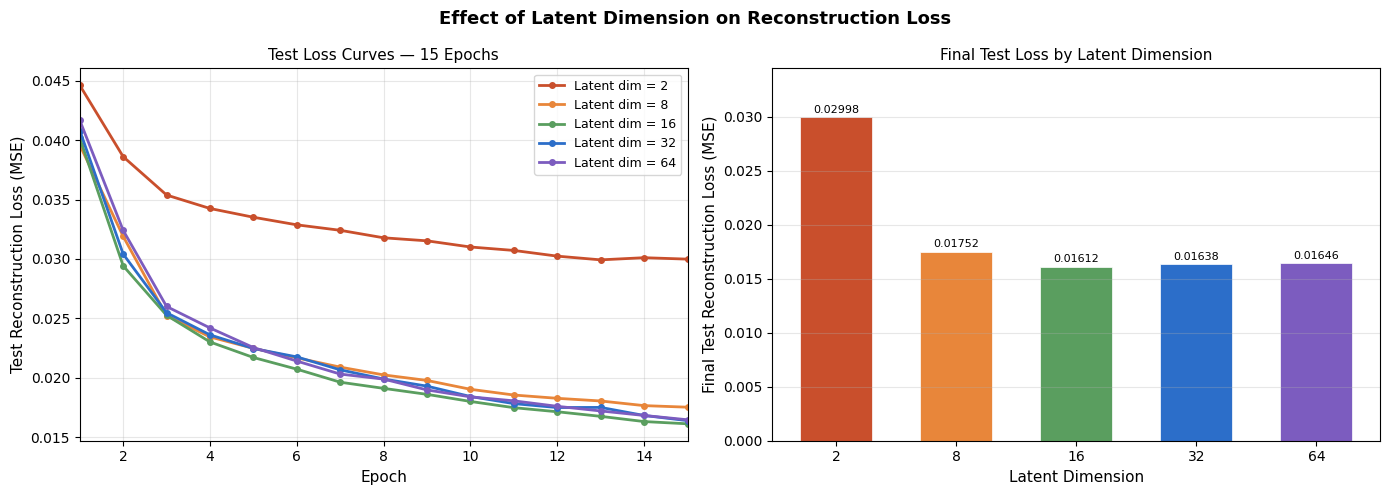

Summary Table
  Latent Dim   Final Test Loss   Compression
--------------------------------------------
           2          0.029981       392.0:1
           8          0.017517        98.0:1
          16          0.016119        49.0:1 ← best
          32          0.016385        24.5:1
          64          0.016459        12.2:1


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Effect of Latent Dimension on Reconstruction Loss', fontsize=13, fontweight='bold')

# Left: Test loss curves
ax1 = axes[0]
for d in LATENT_DIMS:
    color = COLORS[str(d)]
    ax1.plot(range(1, EPOCHS+1), all_test[d], color=color, linewidth=2,
             marker='o', markersize=4, label=f'Latent dim = {d}')

ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Test Reconstruction Loss (MSE)', fontsize=11)
ax1.set_title('Test Loss Curves — 15 Epochs', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(1, EPOCHS)

# Right: Final test loss bar chart
ax2 = axes[1]
final_losses = [all_test[d][-1] for d in LATENT_DIMS]
bar_colors   = [COLORS[str(d)] for d in LATENT_DIMS]
bars = ax2.bar([str(d) for d in LATENT_DIMS], final_losses,
               color=bar_colors, edgecolor='white', linewidth=0.5, width=0.6)

# Annotate bars with values
for bar, loss in zip(bars, final_losses):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
             f'{loss:.5f}', ha='center', va='bottom', fontsize=8)

ax2.set_xlabel('Latent Dimension', fontsize=11)
ax2.set_ylabel('Final Test Reconstruction Loss (MSE)', fontsize=11)
ax2.set_title('Final Test Loss by Latent Dimension', fontsize=11)
ax2.grid(True, axis='y', alpha=0.3)
ax2.set_ylim(0, max(final_losses) * 1.15)

plt.tight_layout()
plt.savefig('loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print('Summary Table')
print(f'{"Latent Dim":>12}  {"Final Test Loss":>16}  {"Compression":>12}')
print('-' * 44)
best = min(LATENT_DIMS, key=lambda d: all_test[d][-1])
for d in LATENT_DIMS:
    marker = ' ← best' if d == best else ''
    print(f'{d:>12}  {all_test[d][-1]:>16.6f}  {round(784/d,1):>10.1f}:1{marker}')

## SSIM: Perceptual Quality Metric

MSE treats all pixels equally. **SSIM (Structural Similarity Index)** is a perceptual metric that accounts for luminance, contrast, and structure. It better captures what humans perceive as visual quality.

SSIM ranges from 0 (no similarity) to 1 (perfect match). Higher is better.

Computing SSIM scores (perceptual quality metric)...
  latent_dim=  2  SSIM = 0.5351
  latent_dim=  8  SSIM = 0.6570
  latent_dim= 16  SSIM = 0.6726
  latent_dim= 32  SSIM = 0.6666
  latent_dim= 64  SSIM = 0.6642


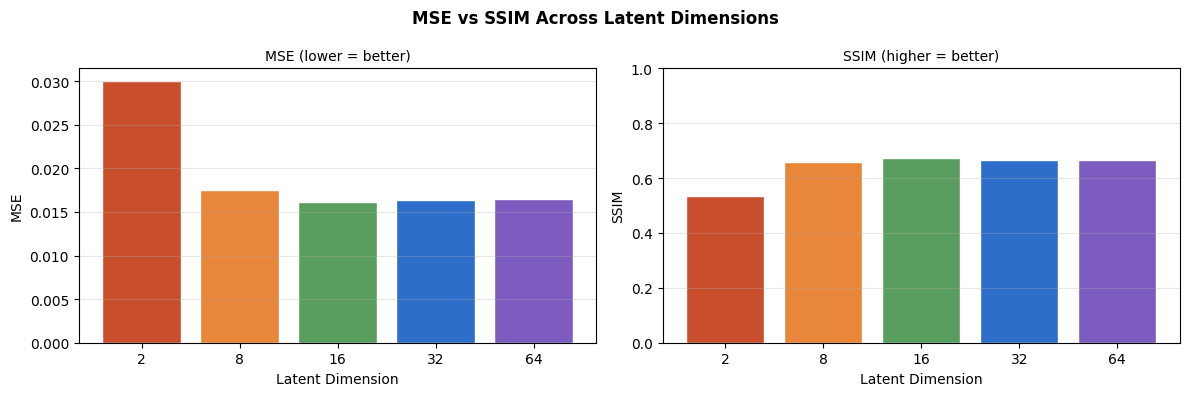

Figure saved: mse_vs_ssim.png

Note: SSIM often tells a similar story to MSE but can diverge — both are useful.


In [6]:
def compute_ssim(model, loader, n_samples=200):
    """Compute mean SSIM between originals and reconstructions."""
    model.eval()
    ssim_scores = []
    count = 0

    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            recons = model(images)

            # Convert to numpy for SSIM calculation
            orig_np  = images.cpu().numpy().squeeze()
            recon_np = recons.cpu().numpy().squeeze()

            for o, r in zip(orig_np, recon_np):
                score = ssim(o, r, data_range=1.0)
                ssim_scores.append(score)
                count += 1
                if count >= n_samples:
                    return np.mean(ssim_scores)

    return np.mean(ssim_scores)


print('Computing SSIM scores (perceptual quality metric)...')
ssim_scores = {}
for d in LATENT_DIMS:
    ssim_scores[d] = compute_ssim(models[d], test_loader)
    print(f'  latent_dim={d:3d}  SSIM = {ssim_scores[d]:.4f}')

# Plot SSIM alongside MSE for comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('MSE vs SSIM Across Latent Dimensions', fontsize=12, fontweight='bold')

dims_str = [str(d) for d in LATENT_DIMS]
colors   = [COLORS[str(d)] for d in LATENT_DIMS]

axes[0].bar(dims_str, [all_test[d][-1] for d in LATENT_DIMS], color=colors, edgecolor='white')
axes[0].set_title('MSE (lower = better)', fontsize=10)
axes[0].set_xlabel('Latent Dimension')
axes[0].set_ylabel('MSE')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(dims_str, [ssim_scores[d] for d in LATENT_DIMS], color=colors, edgecolor='white')
axes[1].set_title('SSIM (higher = better)', fontsize=10)
axes[1].set_xlabel('Latent Dimension')
axes[1].set_ylabel('SSIM')
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('mse_vs_ssim.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: mse_vs_ssim.png')
print('\nNote: SSIM often tells a similar story to MSE but can diverge, both are useful.')

## Visual Reconstructions

Numbers alone do not tell the full story. Here we show the same test images reconstructed by each model.

- **Row 0** = original images  
- **Rows 1–5** = reconstructions from latent dim = 2, 8, 16, 32, 64  

Look for: blurriness at dim=2, sharpening as dimension increases, and where gains plateau visually.

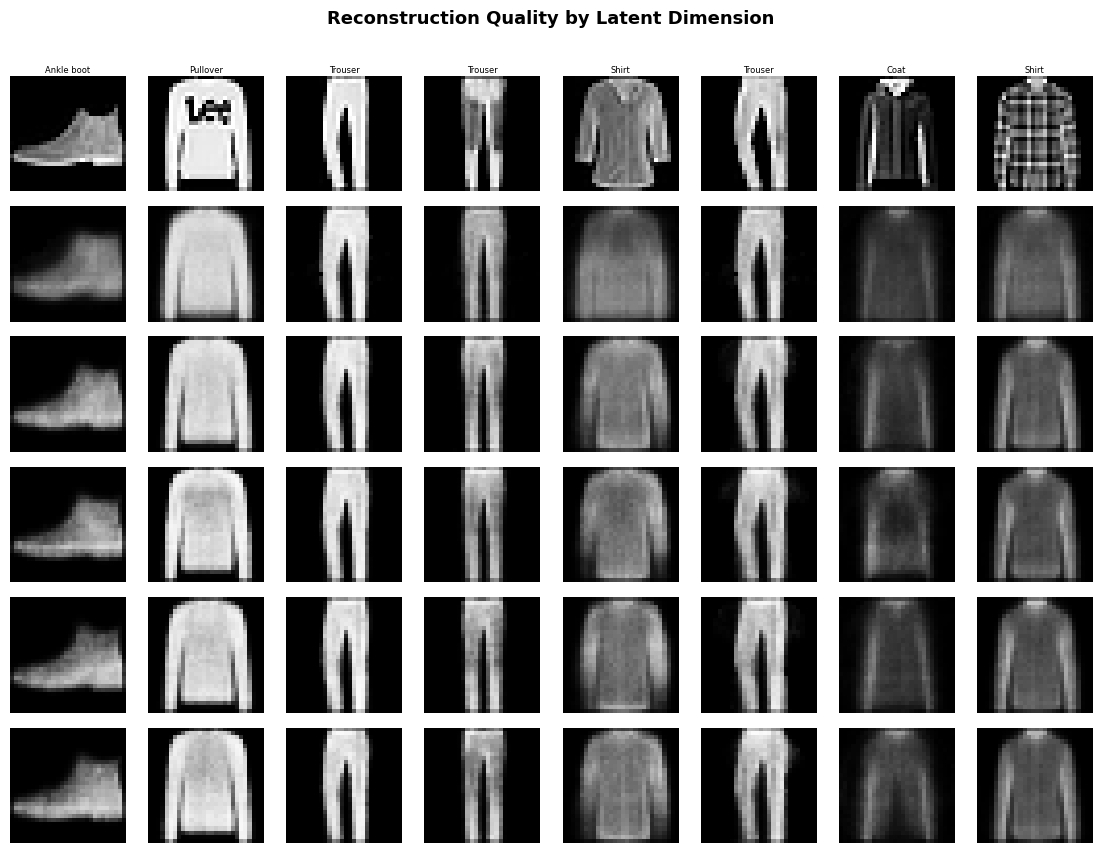

Figure saved: reconstruction_grid.png


In [7]:
N_EXAMPLES = 8  # number of images to show

# Get a fixed batch of test images
test_imgs, test_labels = next(iter(test_loader))
test_imgs = test_imgs[:N_EXAMPLES].to(device)

# Get reconstructions from each model
all_recons = {}
for d in LATENT_DIMS:
    models[d].eval()
    with torch.no_grad():
        all_recons[d] = models[d](test_imgs).cpu()

# Plot grid
rows   = 1 + len(LATENT_DIMS)  # original + one row per latent dim
fig, axes = plt.subplots(rows, N_EXAMPLES, figsize=(N_EXAMPLES * 1.4, rows * 1.4))
fig.suptitle('Reconstruction Quality by Latent Dimension', fontsize=13, fontweight='bold', y=1.01)

row_labels = ['Original'] + [f'Latent={d}' for d in LATENT_DIMS]

for row_idx, label in enumerate(row_labels):
    for col_idx in range(N_EXAMPLES):
        ax = axes[row_idx, col_idx]

        if row_idx == 0:
            img = test_imgs[col_idx].cpu().squeeze()
            ax.set_title(CLASS_NAMES[test_labels[col_idx].item()], fontsize=6, pad=2)
        else:
            d = LATENT_DIMS[row_idx - 1]
            img = all_recons[d][col_idx].squeeze()

        ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        ax.axis('off')

        if col_idx == 0:
            color = COLORS.get(str(LATENT_DIMS[row_idx-1]), '#333') if row_idx > 0 else '#333'
            ax.set_ylabel(label, fontsize=8, color=color, rotation=0,
                          ha='right', va='center', labelpad=50)

plt.tight_layout()
plt.savefig('reconstruction_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: reconstruction_grid.png')

## 2D Latent Space Visualisation

When `latent_dim=2`, we can directly plot every test image as a point in 2D space.

**What to look for:** Even though the model was trained *without* class labels, does it learn to group similar items together? Any clustering reveals that the autoencoder has learnt genuine structure in the data.

**Accessibility note:** This plot uses both colour *and* marker shape to distinguish classes, making it usable by colour-blind readers.

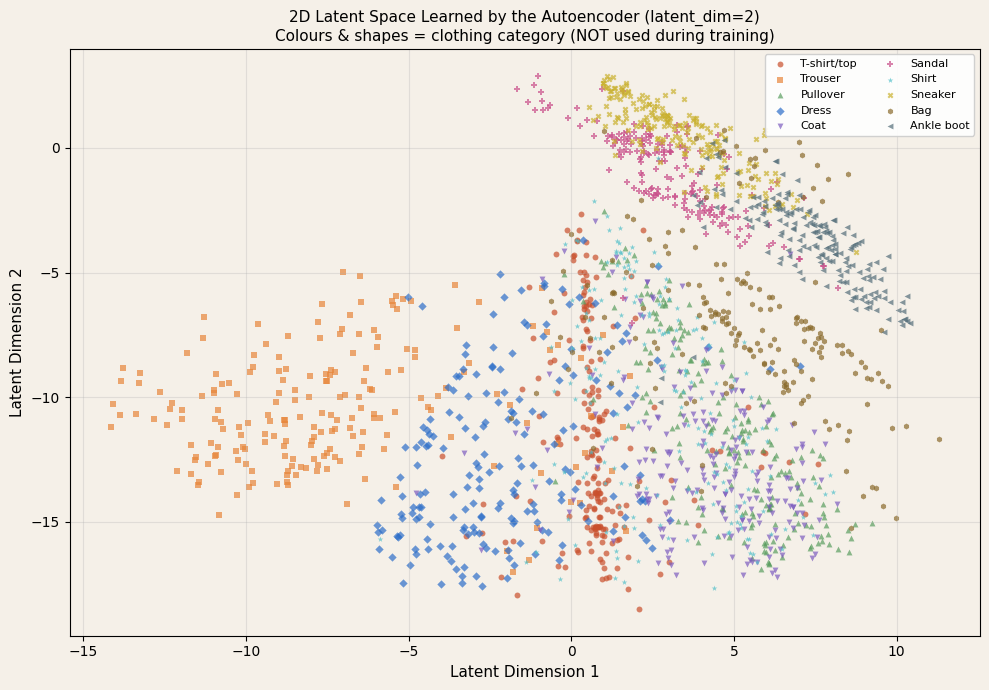

Figure saved: latent_space_2d.png

Key observation: loose clustering visible despite no class labels used in training.
The autoencoder has learned that visually similar items compress similarly.


In [8]:
# Encode all test images using the dim=2 model
model_2d = models[2]
model_2d.eval()

latent_points = []
labels_list   = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        z = model_2d.encode(images)   # shape: (batch, 2)
        latent_points.append(z.cpu().numpy())
        labels_list.append(labels.numpy())

latent_points = np.concatenate(latent_points, axis=0)
labels_arr    = np.concatenate(labels_list,   axis=0)

# Plot — colour + shape markers for accessibility
PALETTE  = ['#c94f2c','#e8863a','#5a9e5f','#2c6ec9','#7c5cbf',
            '#c94f8a','#4fbfc9','#c9b02c','#8a6b2c','#546e7a']
MARKERS  = ['o','s','^','D','v','P','*','X','h','<']

fig, ax = plt.subplots(figsize=(10, 7))
ax.set_facecolor('#f5f0e8')
fig.patch.set_facecolor('#f5f0e8')

for class_idx, class_name in enumerate(CLASS_NAMES):
    mask = labels_arr == class_idx
    ax.scatter(
        latent_points[mask, 0], latent_points[mask, 1],
        c=PALETTE[class_idx], marker=MARKERS[class_idx],
        s=18, alpha=0.7, label=class_name, linewidths=0
    )

ax.set_xlabel('Latent Dimension 1', fontsize=11)
ax.set_ylabel('Latent Dimension 2', fontsize=11)
ax.set_title('2D Latent Space Learned by the Autoencoder (latent_dim=2)\n'
             'Colours & shapes = clothing category (NOT used during training)',
             fontsize=11)
ax.legend(loc='upper right', fontsize=8, ncol=2, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('latent_space_2d.png', dpi=150, bbox_inches='tight')
plt.show()

print('Figure saved: latent_space_2d.png')
print('\nKey observation: loose clustering visible despite no class labels used in training.')
print('The autoencoder has learned that visually similar items compress similarly.')

## Latent Space Interpolation

One of the most powerful ways to understand what the latent space has learned is **interpolation**: take two images, encode them, linearly interpolate between their latent vectors, and decode each step.

If the latent space is smooth, the images should transition gradually. Abrupt jumps reveal gaps in the latent space.

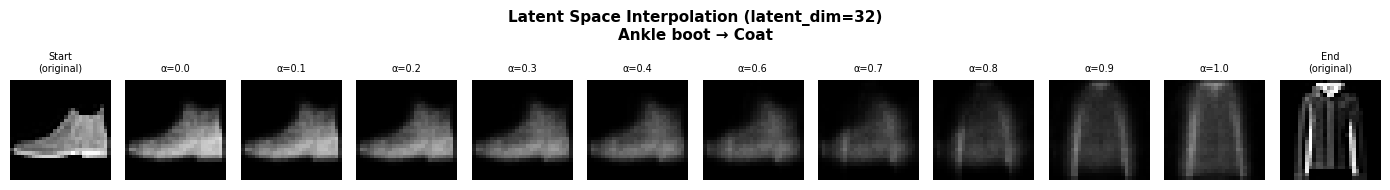

Figure saved: latent_interpolation.png
Smooth transitions indicate a well-structured latent space.


In [9]:
def interpolate_latent(model, img_a, img_b, steps=10):
    """
    Linearly interpolate between two images in latent space.
    Returns decoded images at each interpolation step.
    """
    model.eval()
    with torch.no_grad():
        z_a = model.encode(img_a.unsqueeze(0).to(device))
        z_b = model.encode(img_b.unsqueeze(0).to(device))

        interpolated = []
        for alpha in np.linspace(0, 1, steps):
            z_mid = (1 - alpha) * z_a + alpha * z_b
            decoded = model.decode(z_mid)
            interpolated.append(decoded.squeeze().cpu())

    return interpolated


# Use dim=32 for a cleaner interpolation
model_32 = models[32]
STEPS = 10

# Pick two different clothing items from the test set
img_a, label_a = test_full[0]
img_b, label_b = test_full[1]

# Find a shoe and a coat for interesting contrast
for idx in range(len(test_full)):
    img, lbl = test_full[idx]
    if lbl == 9:  # Ankle boot
        img_a, label_a = img, lbl
        break

for idx in range(len(test_full)):
    img, lbl = test_full[idx]
    if lbl == 4:  # Coat
        img_b, label_b = img, lbl
        break

frames = interpolate_latent(model_32, img_a, img_b, steps=STEPS)

fig, axes = plt.subplots(1, STEPS + 2, figsize=(14, 2))
fig.suptitle(f'Latent Space Interpolation (latent_dim=32)\n'
             f'{CLASS_NAMES[label_a]} → {CLASS_NAMES[label_b]}',
             fontsize=11, fontweight='bold')

# Show start
axes[0].imshow(img_a.squeeze(), cmap='gray')
axes[0].set_title('Start\n(original)', fontsize=7)
axes[0].axis('off')

# Show interpolated frames
for i, frame in enumerate(frames):
    axes[i+1].imshow(frame, cmap='gray', vmin=0, vmax=1)
    axes[i+1].set_title(f'α={i/(STEPS-1):.1f}', fontsize=7)
    axes[i+1].axis('off')

# Show end
axes[-1].imshow(img_b.squeeze(), cmap='gray')
axes[-1].set_title('End\n(original)', fontsize=7)
axes[-1].axis('off')

plt.tight_layout()
plt.savefig('latent_interpolation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Smooth transitions indicate a well-structured latent space.')

## Finding the 'Elbow' : Choosing a Latent Dimension

A practical strategy is to plot loss as a function of latent dimension and look for the **elbow** the point of diminishing returns where adding more dimensions gives little extra reconstruction quality.

This is the sweet spot: large enough to be informative, small enough to force genuine compression.

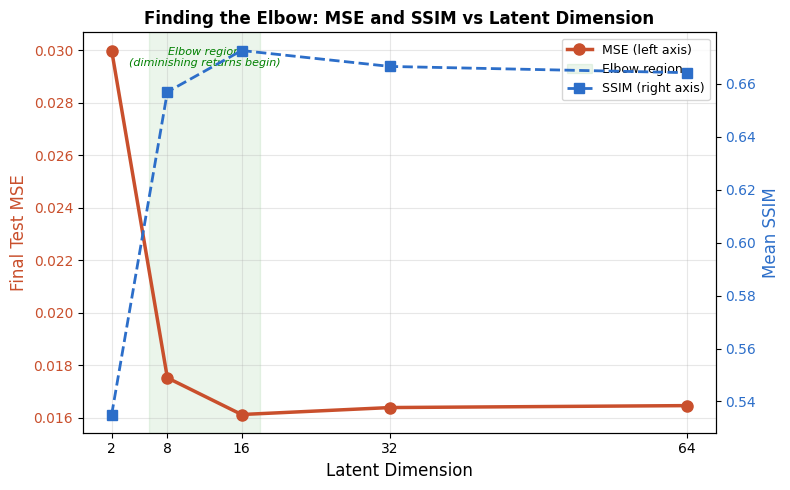

Figure saved: elbow_plot.png


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

final_mse  = [all_test[d][-1] for d in LATENT_DIMS]
final_ssim = [ssim_scores[d]  for d in LATENT_DIMS]

# MSE line
ax.plot(LATENT_DIMS, final_mse, 'o-', color='#c94f2c', linewidth=2.5,
        markersize=8, label='MSE (left axis)')
ax.set_xlabel('Latent Dimension', fontsize=12)
ax.set_ylabel('Final Test MSE', fontsize=12, color='#c94f2c')
ax.tick_params(axis='y', labelcolor='#c94f2c')

# SSIM on secondary axis
ax2 = ax.twinx()
ax2.plot(LATENT_DIMS, final_ssim, 's--', color='#2c6ec9', linewidth=2,
         markersize=7, label='SSIM (right axis)')
ax2.set_ylabel('Mean SSIM', fontsize=12, color='#2c6ec9')
ax2.tick_params(axis='y', labelcolor='#2c6ec9')

# Annotate elbow region
ax.axvspan(6, 18, alpha=0.08, color='green', label='Elbow region')
ax.text(12, max(final_mse)*0.98, 'Elbow region\n(diminishing returns begin)',
        ha='center', fontsize=8, color='green', style='italic')

ax.set_title('Finding the Elbow: MSE and SSIM vs Latent Dimension', fontsize=12, fontweight='bold')
ax.set_xticks(LATENT_DIMS)
ax.grid(True, alpha=0.3)

# Combine legends
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: elbow_plot.png')

## Summary & Conclusions

A final summary of all key metrics across latent dimensions.

In [11]:
print('  FINAL RESULTS SUMMARY')
print(f'{"Dim":>5}  {"Compression":>12}  {"Final MSE":>12}  {"SSIM":>8}  {"Assessment"}')

# Dynamically find the best latent dimension so the summary always matches the results
best_dim = min(LATENT_DIMS, key=lambda x: all_test[x][-1])

assessments = {
    2: 'Severe over-compression',
    8: 'Large gain vs dim=2',
    16: 'Marginal improvement',
    32: 'Good reconstruction',
    64: 'Strong reconstruction'
}
assessments[best_dim] = 'Best MSE (this run) ★'

for d in LATENT_DIMS:
    print(
        f'{d:>5}  {round(784/d,1):>9.1f}:1  '
        f'{all_test[d][-1]:>12.6f}  '
        f'{ssim_scores[d]:>8.4f}  {assessments[d]}'
    )


  FINAL RESULTS SUMMARY
  Dim   Compression     Final MSE      SSIM  Assessment
    2      392.0:1      0.029981    0.5351  Severe over-compression
    8       98.0:1      0.017517    0.6570  Large gain vs dim=2
   16       49.0:1      0.016119    0.6726  Best MSE (this run) ★
   32       24.5:1      0.016385    0.6666  Good reconstruction
   64       12.2:1      0.016459    0.6642  Strong reconstruction


## Key findings:
1. Latent dim=2 causes severe information loss and substantially higher MSE than dim=8.
2. The biggest single gain is between dim=2 and dim=8.
3. Gains diminish beyond dim=8, with an elbow around dim=8-16.
4. Dim=16 achieves the lowest MSE in this experiment.
5. Even without labels, the 2D latent space shows emergent class clustering.

Practical guidance:
- For visualisation only: dim = 2-3
- For strong compression with good reconstruction: dim = 8-16
- For higher-capacity latent features: dim = 32-64
- For generative sampling: consider a VAE

See also: the accompanying GitHub repository for the full notebook and code.

## References

Cover, T.M. and Thomas, J.A. (2006) *Elements of Information Theory*. 2nd edn. Wiley-Interscience.

Goodfellow, I., Bengio, Y. and Courville, A. (2016) *Deep Learning*. MIT Press. https://www.deeplearningbook.org

Hinton, G.E. and Salakhutdinov, R.R. (2006) 'Reducing the dimensionality of data with neural networks', *Science*, 313(5786), pp. 504–507. https://doi.org/10.1126/science.1127647

Kingma, D.P. and Welling, M. (2014) 'Auto-encoding variational bayes'. arXiv:1312.6114. https://arxiv.org/abs/1312.6114

PyTorch (2024) Documentation. https://pytorch.org/docs

Vincent, P. et al. (2010) 'Stacked denoising autoencoders', *JMLR*, 11, pp. 3371–3408.

Wang, Z. et al. (2004) 'Image quality assessment: from error visibility to structural similarity', *IEEE TIP*, 13(4), pp. 600–612. (SSIM paper)

Xiao, H., Rasul, K. and Vollgraf, R. (2017) Fashion-MNIST. arXiv:1708.07747. https://arxiv.org/abs/1708.07747